# TensorFlow - Air Pollution Forecasting

https://www.kaggle.com/datasets/rupakroy/lstm-datasets-multivariate-univariate?select=LSTM-Multivariate_pollution.csv

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler  
from tensorflow.keras.models import Sequential  
from tensorflow.keras.layers import Dense, LSTM 

In [3]:
raw = pd.read_csv('data/Multivariate_pollution.csv') # Extract data

raw['date'] = pd.to_datetime(raw['date'])            # Convert 'date' column to datetime format
raw.set_index('date', inplace=True)                  # Set 'date' as index
raw_numeric = raw.select_dtypes(include='number')    # Select only numeric columns

df = raw_numeric.resample('D').mean()                # Aggregate by day (take daily mean)

df.head() 

,pollution,dew,temp,press,wnd_spd,snow,rain
date,,,,,,,
2010-01-02,145.958333,-8.500000,-5.125000,1024.750000,24.860000,0.708333,0.0
2010-01-03,78.833333,-10.125000,-8.541667,1022.791667,70.937917,14.166667,0.0
2010-01-04,31.333333,-20.875000,-11.500000,1029.291667,111.160833,0.000000,0.0
2010-01-05,42.458333,-24.583333,-14.458333,1033.625000,56.920000,0.000000,0.0
2010-01-06,56.416667,-23.708333,-12.541667,1033.750000,18.511667,0.000000,0.0


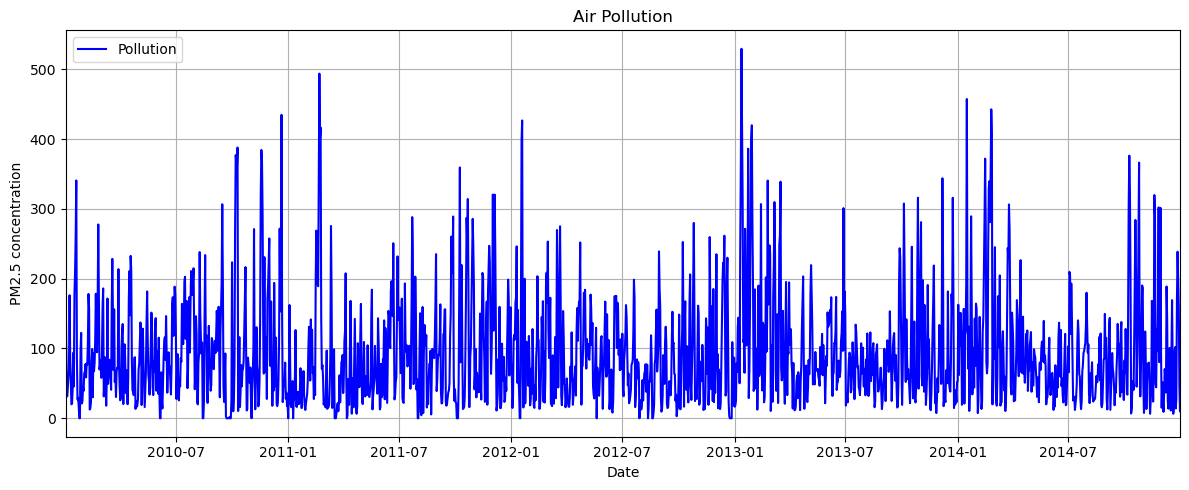

In [4]:
# Plot actual and fitted serie
plt.figure(figsize=(12, 5))                                      

plt.plot(df.index, df['pollution'], label='Pollution', color='blue')     

plt.title('Air Pollution')                      
plt.xlabel('Date')                                        
plt.ylabel('PM2.5 concentration')  
plt.xlim(pd.to_datetime('2010-01-02'), pd.to_datetime('2014-12-31'))
#plt.ticklabel_format(style='plain', axis='y')  # Disable scientific notation on y-axis
plt.grid(True)                                            
plt.legend(loc=2)                                             
plt.tight_layout()                                       
plt.show();

In [5]:
# Split the data
cutoff = pd.to_datetime("2014-10-01")

train_df = df[df.index < cutoff]
test_df = df[df.index >= cutoff]

# Show results
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1733, 7)
Test shape: (92, 7)


# TensorFlow - Univariate

In [6]:
# Prepare series and time 
series = df['pollution'].values        # Get pollution series as numpy array
time = np.arange(len(series))          # Create time index

In [7]:
# Define the split time
split_time = 1733                      # Alternative: int(0.8 * len(series_scaled))

# Get the train set 
time_train = time[:split_time]         # Training time
x_train = series[:split_time]          # Training values

# Get the validation set
time_valid = time[split_time:]         # Validation time
x_valid = series[split_time:]          # Validation values

print("     Total size:",len(x_train)+len(x_valid))
print("     Train size:",len(x_train))
print("Validation size:",len(x_valid))

     Total size: 1825
     Train size: 1733
Validation size: 92


In [8]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
  
    dataset = tf.data.Dataset.from_tensor_slices(series)                       # Generate a TF Dataset from the series values   
    dataset = dataset.window(window_size + 1, shift=1, drop_remainder=True)    # Window the data but only take those with the specified size   
    dataset = dataset.flat_map(lambda window: window.batch(window_size + 1))   # Flatten the windows by putting its elements in a single batch
    dataset = dataset.map(lambda window: (window[:-1], window[-1]))            # Create tuples with features and labels 
    dataset = dataset.shuffle(shuffle_buffer)                                  # Shuffle the windows  
    dataset = dataset.batch(batch_size)                                        # Create batches of windows   
    dataset = dataset.cache().prefetch(1)                                      # Optimize the dataset for training
    
    return dataset


# Define parameters for windowing
window_size = 30              # Number of time steps used as input features
batch_size = 32               # Number of samples per batch for training
shuffle_buffer_size = 500     # Buffer size for shuffling the dataset

# Generate the dataset windows using x_train
train_set = windowed_dataset(x_train, window_size, batch_size, shuffle_buffer_size)

In [9]:
# Build the model
model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(window_size, 1)),       # Input: 3D shape [batch, time_step, features]
        tf.keras.layers.Conv1D(filters=32, kernel_size=5,    # How many feature maps to learn; looks at 5 time steps at a time
                               strides=1, padding="causal",  # Moves the window one step at a time; padding only at the beginning
                               activation="relu"),           # Applies ReLU activation to introduce non-linearity
        tf.keras.layers.LSTM(64, return_sequences=True),     # Captures long-term dependencies in sequence data (returning sequences)
        tf.keras.layers.LSTM(64),                            # Captures long-term dependencies in sequence data (returning last output only)
        tf.keras.layers.Dense(30, activation="relu"),        # Help with final prediction after feature extraction
        tf.keras.layers.Dense(10, activation="relu"),        # Help with final prediction after feature extraction
        tf.keras.layers.Dense(1)                             # Output layer for a single forecasted value
])

# Print the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 30, 32)              │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 30, 64)              │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 30)                  │           1,950 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             310 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 60,319 (235.62 KB)

 Trainable params: 60,319 (235.62 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Compile the model
model.compile(
    loss=tf.keras.losses.Huber(),            # Robust loss for outliers
    optimizer=tf.keras.optimizers.Adam(),    # Adaptive optimizer
    metrics=["mae"]                          # Mean Absolute Error as evaluation metric
)

steps_per_epoch = len(x_train) - window_size # Manually set steps_per_epoch


# Train the model
history = model.fit(train_set, epochs=100, steps_per_epoch=steps_per_epoch)

Epoch 1/100
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 2s 288us/step - loss: 85.5157 - mae: 86.0141
Epoch 2/100
  13/1703 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 79.0099 - mae: 79.5093  

C:\Users\lsoares\AppData\Local\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1703/1703 ━━━━━━━━━━━━━━━━━━━━ 1s 286us/step - loss: 65.9351 - mae: 66.4342
Epoch 3/100
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 0s 264us/step - loss: 55.3032 - mae: 55.8010
Epoch 4/100
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 0s 277us/step - loss: 54.3919 - mae: 54.8890
Epoch 5/100
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 1s 288us/step - loss: 54.3582 - mae: 54.8559
Epoch 6/100
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 0s 262us/step - loss: 52.0806 - mae: 52.5787
Epoch 7/100
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 0s 259us/step - loss: 48.7744 - mae: 49.2722
Epoch 8/100
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 0s 253us/step - loss: 47.1690 - mae: 47.6655
Epoch 9/100
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 0s 253us/step - loss: 46.5010 - mae: 46.9981
Epoch 10/100
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 0s 286us/step - loss: 45.8106 - mae: 46.3080
Epoch 11/100
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 0s 278us/step - loss: 45.6562 - mae: 46.1534
Epoch 12/100
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 0s 272us/step - loss: 45.1626 - mae: 45.6584
Epoch 13/100
1703/1703 ━━━━━━━━━━━━━━━━━━

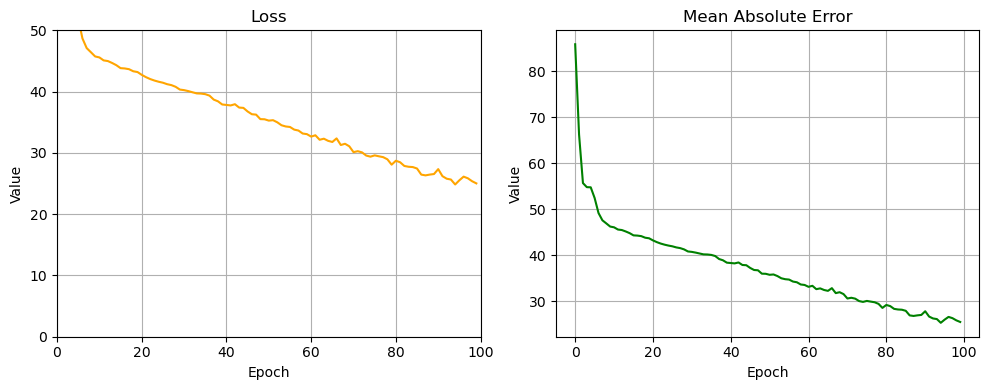

In [11]:
# Create a 1x2 grid for subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))  

# Plot AutoCorrelation Function
axes[0].plot(history.history["loss"], color='orange')
axes[0].set_title("Loss", fontsize=12)
axes[0].set_ylabel("Value")
axes[0].set_xlabel("Epoch")
axes[0].set_xlim(0,100)
axes[0].set_ylim(0,50)
axes[0].grid(True)

# Plot Partial Autocorrelation Function
axes[1].plot(history.history["mae"], color='green')
axes[1].set_title("Mean Absolute Error", fontsize=12)
axes[1].set_ylabel("Value")
axes[1].set_xlabel("Epoch")
axes[1].grid(True)

plt.tight_layout()
plt.show();

In [12]:
def model_forecast(model, series, window_size, batch_size):

    dataset = tf.data.Dataset.from_tensor_slices(series)                 # Generate a TF Dataset from the series values
    dataset = dataset.window(window_size, shift=1, drop_remainder=True)  # Window the data but only take those with the specified size
    dataset = dataset.flat_map(lambda w: w.batch(window_size))           # Flatten the windows by putting its elements in a single batch
    dataset = dataset.batch(batch_size).prefetch(1)                      # Create batches of windows    
    forecast = model.predict(dataset, verbose=0)                         # Get predictions on the entire dataset
    
    return forecast


# Reduce the original series
forecast_series = series[split_time-window_size:-1]

# Use helper function to generate predictions
forecast = model_forecast(model, forecast_series, window_size, batch_size)

# Drop single dimensional axis
results = forecast.squeeze()

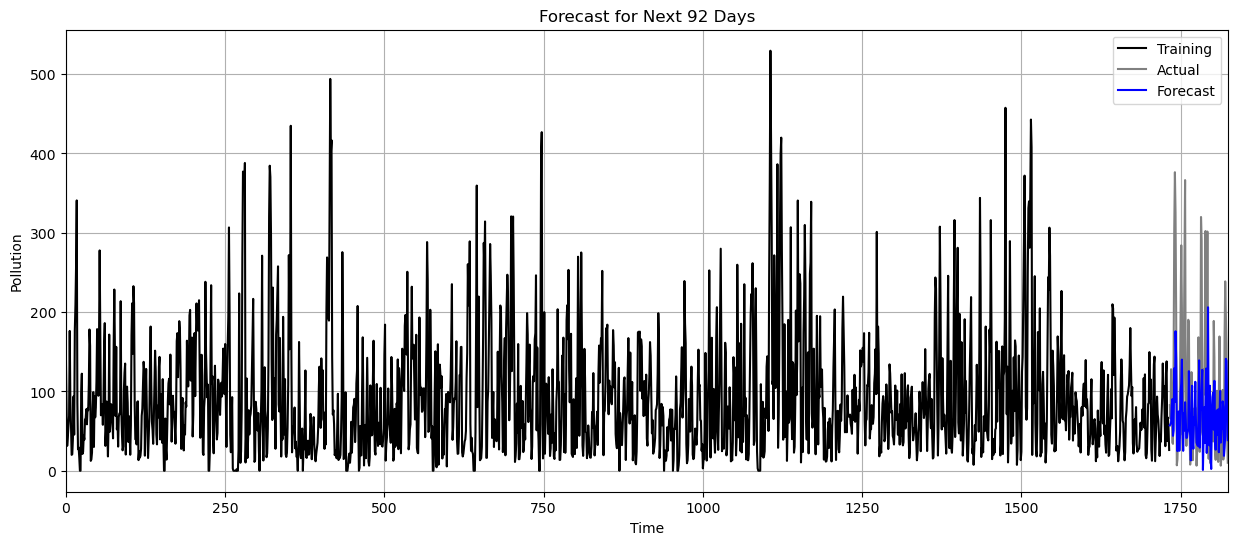

In [13]:
# Plot actual vs. forecast
plt.figure(figsize=(15, 6))
plt.plot(time_train, x_train, label="Training", color='black')    # Train values
plt.plot(time_valid, x_valid, label="Actual", color='gray')       # Validation values
plt.plot(time_valid, results, label="Forecast", color='blue')  # Forecast values
plt.title("Forecast for Next 92 Days")
plt.xlim(0, 1825)
plt.xlabel("Time")
plt.ylabel("Pollution")
plt.legend()
plt.grid(True)
plt.show();

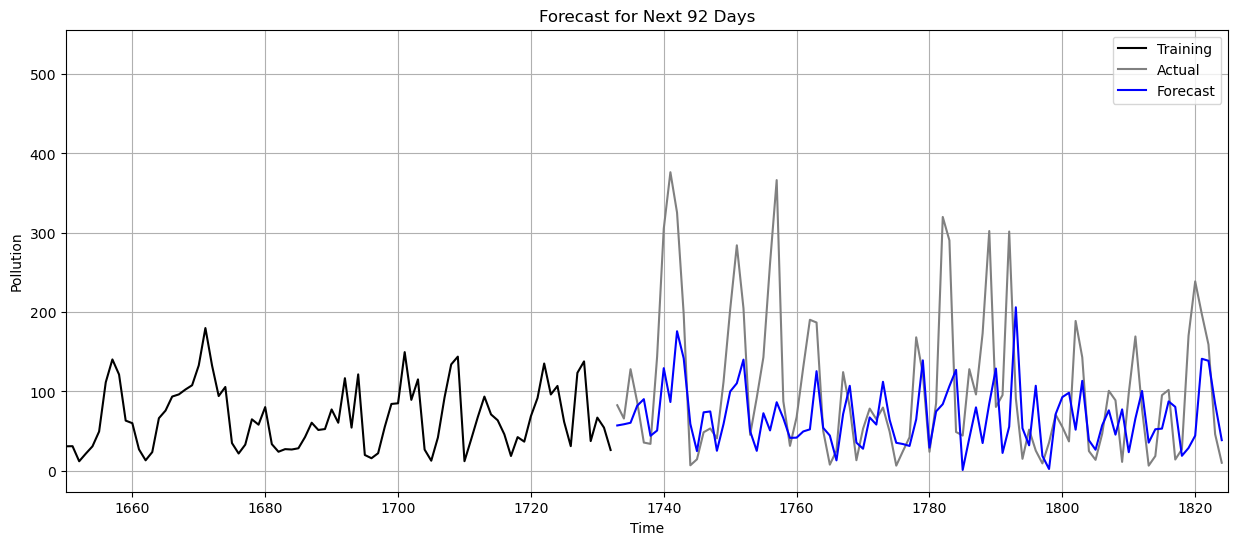

In [14]:
# Plot actual vs. forecast
plt.figure(figsize=(15, 6))
plt.plot(time_train, x_train, label="Training", color='black')    # Train values
plt.plot(time_valid, x_valid, label="Actual", color='gray')       # Validation values
plt.plot(time_valid, results, label="Forecast", color='blue')  # Forecast values
plt.title("Forecast for Next 92 Days")
plt.xlim(1650, 1825)
plt.xlabel("Time")
plt.ylabel("Pollution")
plt.legend()
plt.grid(True)
plt.show();

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

mae = mean_absolute_error(x_valid, results)
rmse = np.sqrt(mean_squared_error(x_valid, results))

print(f" MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

 MAE: 63.39
RMSE: 91.85


## KerasTuner

In [16]:
import numpy as np
import tensorflow as tf
import keras_tuner as kt

# === Step 1: Your original data split ===
split_time = 1733                            # Set split time
x_train = series[:split_time]                # Training values
x_valid = series[split_time:]                # Validation values

print("     Total size:", len(x_train) + len(x_valid))
print("     Train size:", len(x_train))
print("Validation size:", len(x_valid))

# === Step 2: Create windowed datasets ===
window_size = 30
batch_size = 32

def create_windowed_dataset(series, window_size, batch_size):
    series = np.expand_dims(series, axis=-1)                          # Add channel dimension
    X = []
    y = []
    for i in range(len(series) - window_size):
        X.append(series[i:i + window_size])                           # Input window
        y.append(series[i + window_size])                             # Next value
    X = np.array(X)
    y = np.array(y)
    return tf.data.Dataset.from_tensor_slices((X, y)).batch(batch_size).prefetch(1)

train_dataset = create_windowed_dataset(x_train, window_size, batch_size)
valid_dataset = create_windowed_dataset(x_valid, window_size, batch_size)

# === Step 3: Define model builder for Keras Tuner ===
def build_model(hp):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(window_size, 1)))

    model.add(tf.keras.layers.Conv1D(
        filters=hp.Choice("filters", [32, 64]),
        kernel_size=hp.Choice("kernel_size", [3, 5]),
        activation='relu',
        padding='causal'
    ))

    model.add(tf.keras.layers.LSTM(
        hp.Choice("lstm_units_0", [64, 96, 128]),
        return_sequences=True
    ))

    model.add(tf.keras.layers.LSTM(
        hp.Choice("lstm_units_1", [32, 64])
    ))

    model.add(tf.keras.layers.Dense(
        hp.Choice("dense_units", [16, 32]),
        activation='relu'
    ))

    model.add(tf.keras.layers.Dense(1))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            hp.Choice("learning_rate", [1e-2, 1e-3])
        ),
        loss=tf.keras.losses.Huber(),
        metrics=["mae"]
    )

    return model

# === Step 4: Run tuner ===
tuner = kt.RandomSearch(
    build_model,
    objective="val_mae",
    max_trials=10,
    executions_per_trial=1,
    overwrite=True,
    directory="tuner_dir",
    project_name="forecast_tuning"
)

tuner.search(train_dataset, validation_data=valid_dataset, epochs=20)


Trial 10 Complete [00h 00m 17s]
val_mae: 51.37305450439453

Best val_mae So Far: 50.01407241821289
Total elapsed time: 00h 02m 38s


In [17]:
# Get the best trial
best_hps = tuner.get_best_hyperparameters(1)[0]

# Print all selected hyperparameters
print("Best Hyperparameters Found:")
print(f"Filters (Conv1D):         {best_hps.get('filters')}")
print(f"Kernel Size (Conv1D):     {best_hps.get('kernel_size')}")
print(f"LSTM Units Layer 0:       {best_hps.get('lstm_units_0')}")
print(f"LSTM Units Layer 1:       {best_hps.get('lstm_units_1')}")
print(f"Dense Units:              {best_hps.get('dense_units')}")
print(f"Learning Rate:            {best_hps.get('learning_rate')}")

Best Hyperparameters Found:
Filters (Conv1D):         32
Kernel Size (Conv1D):     3
LSTM Units Layer 0:       96
LSTM Units Layer 1:       32
Dense Units:              32
Learning Rate:            0.01


In [18]:
# Build final model with best hyperparameters
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(window_size, 1)),                            # Input shape: (time_steps, 1)
    tf.keras.layers.Conv1D(filters=64, kernel_size=3,                         # Best: filters=64, kernel_size=5
                           strides=1, padding="causal", activation="relu"),
    tf.keras.layers.LSTM(64, return_sequences=True),                          # Best: 96 units
    tf.keras.layers.LSTM(64),                                                 # Best: 64 units
    tf.keras.layers.Dense(32, activation="relu"),                             # Best: 32 dense units
    tf.keras.layers.Dense(1)                                                  # Output layer
])

model.summary()

# Compile with best learning rate
model.compile(
    loss=tf.keras.losses.Huber(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),                  # Best: 0.001
    metrics=["mae"]
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)                    │ (None, 30, 64)              │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 30, 64)              │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 68,417 (267.25 KB)

 Trainable params: 68,417 (267.25 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Manually set steps_per_epoch
steps_per_epoch = len(x_train) - window_size 

# Train the model
history = model.fit(train_set, epochs=200, steps_per_epoch=steps_per_epoch)

Epoch 1/200
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 2s 288us/step - loss: 79.0152 - mae: 79.5125
Epoch 2/200
  19/1703 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 69.3098 - mae: 69.8069

C:\Users\lsoares\AppData\Local\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1703/1703 ━━━━━━━━━━━━━━━━━━━━ 1s 291us/step - loss: 59.8805 - mae: 60.3777
Epoch 3/200
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 0s 272us/step - loss: 54.7406 - mae: 55.2388
Epoch 4/200
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 0s 283us/step - loss: 53.9984 - mae: 54.4963
Epoch 5/200
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 0s 276us/step - loss: 50.6180 - mae: 51.1146
Epoch 6/200
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 0s 284us/step - loss: 48.5287 - mae: 49.0261
Epoch 7/200
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 1s 296us/step - loss: 47.2777 - mae: 47.7759
Epoch 8/200
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 1s 289us/step - loss: 47.4105 - mae: 47.9079
Epoch 9/200
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 1s 290us/step - loss: 46.5847 - mae: 47.0818
Epoch 10/200
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 1s 311us/step - loss: 46.1600 - mae: 46.6579
Epoch 11/200
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 1s 290us/step - loss: 45.9128 - mae: 46.4094
Epoch 12/200
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 1s 292us/step - loss: 45.7751 - mae: 46.2732
Epoch 13/200
1703/1703 ━━━━━━━━━━━━━━━━━━

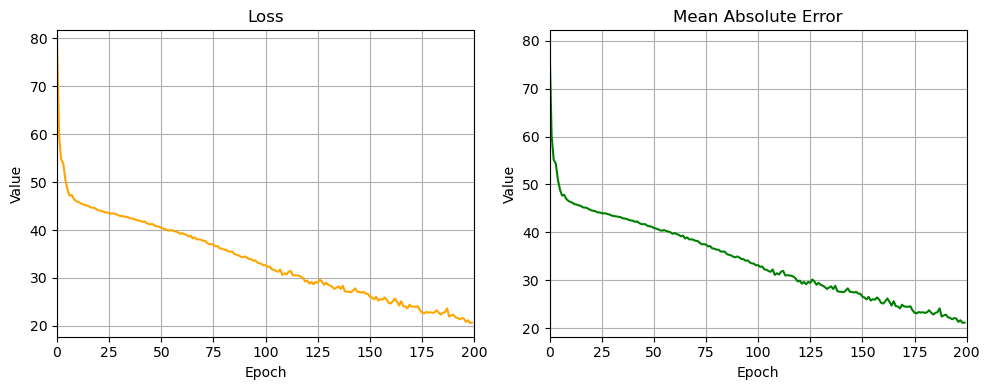

In [20]:
# Create a 1x2 grid for subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))  

# Plot AutoCorrelation Function
axes[0].plot(history.history["loss"], color='orange')
axes[0].set_title("Loss", fontsize=12)
axes[0].set_ylabel("Value")
axes[0].set_xlabel("Epoch")
axes[0].set_xlim(0,200)
axes[0].grid(True)

# Plot Partial Autocorrelation Function
axes[1].plot(history.history["mae"], color='green')
axes[1].set_title("Mean Absolute Error", fontsize=12)
axes[1].set_ylabel("Value")
axes[1].set_xlabel("Epoch")
axes[1].set_xlim(0,200)
axes[1].grid(True)

plt.tight_layout()
plt.show();

In [21]:
def model_forecast(model, series, window_size, batch_size):

    dataset = tf.data.Dataset.from_tensor_slices(series)                 # Generate a TF Dataset from the series values
    dataset = dataset.window(window_size, shift=1, drop_remainder=True)  # Window the data but only take those with the specified size
    dataset = dataset.flat_map(lambda w: w.batch(window_size))           # Flatten the windows by putting its elements in a single batch
    dataset = dataset.batch(batch_size).prefetch(1)                      # Create batches of windows    
    forecast = model.predict(dataset, verbose=0)                         # Get predictions on the entire dataset
    
    return forecast


# Reduce the original series
forecast_series = series[split_time-window_size:-1]

# Use helper function to generate predictions
forecast = model_forecast(model, forecast_series, window_size, batch_size)

# Drop single dimensional axis
results = forecast.squeeze()

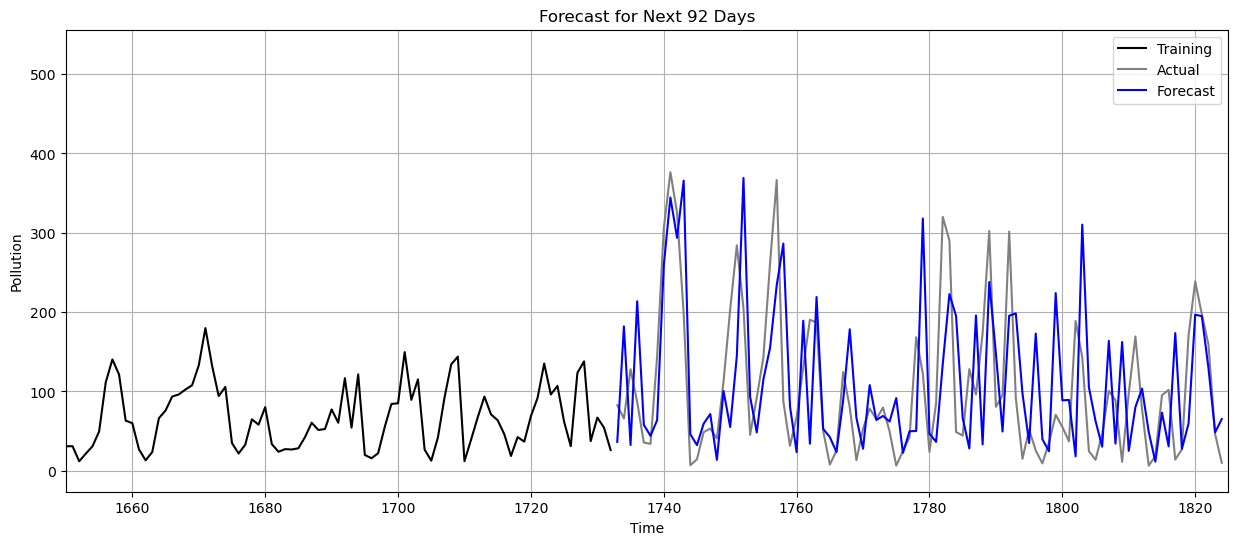

In [22]:
# Plot actual vs. forecast
plt.figure(figsize=(15, 6))
plt.plot(time_train, x_train, label="Training", color='black')    # Train values
plt.plot(time_valid, x_valid, label="Actual", color='gray')       # Validation values
plt.plot(time_valid, results, label="Forecast", color='blue')     # Forecast values
plt.title("Forecast for Next 92 Days")
plt.xlim(1650, 1825)
plt.xlabel("Time")
plt.ylabel("Pollution")
plt.legend()
plt.grid(True)
plt.show();

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

mae = mean_absolute_error(x_valid, results)
rmse = np.sqrt(mean_squared_error(x_valid, results))

print(f" MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

 MAE: 67.42
RMSE: 86.60


# Multivariate Model

In [24]:
raw = pd.read_csv('data/Multivariate_pollution.csv') # Extract data

raw['date'] = pd.to_datetime(raw['date'])            # Convert 'date' column to datetime format
raw.set_index('date', inplace=True)                  # Set 'date' as index
raw_numeric = raw.select_dtypes(include='number')    # Select only numeric columns

df = raw_numeric.resample('D').mean()                # Aggregate by day (take daily mean)

df.head() 

,pollution,dew,temp,press,wnd_spd,snow,rain
date,,,,,,,
2010-01-02,145.958333,-8.500000,-5.125000,1024.750000,24.860000,0.708333,0.0
2010-01-03,78.833333,-10.125000,-8.541667,1022.791667,70.937917,14.166667,0.0
2010-01-04,31.333333,-20.875000,-11.500000,1029.291667,111.160833,0.000000,0.0
2010-01-05,42.458333,-24.583333,-14.458333,1033.625000,56.920000,0.000000,0.0
2010-01-06,56.416667,-23.708333,-12.541667,1033.750000,18.511667,0.000000,0.0


In [25]:
train = df.iloc[:1733]
test = df.iloc[1733:]

# Show results
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print()
print(train.tail())
print()
print(test.head())

Train shape: (1733, 7)
Test shape: (92, 7)

             pollution        dew       temp        press    wnd_spd  snow  \
date                                                                         
2014-09-26  137.833333  16.416667  18.916667  1011.291667   8.495833   0.0   
2014-09-27   37.333333  11.166667  18.458333  1015.875000   3.427083   0.0   
2014-09-28   66.958333  13.958333  18.000000  1016.125000   6.331250   0.0   
2014-09-29   54.375000   8.666667  17.791667  1018.958333   8.119583   0.0   
2014-09-30   26.125000   2.291667  12.458333  1026.041667  10.826250   0.0   

                rain  
date                  
2014-09-26  0.041667  
2014-09-27  0.000000  
2014-09-28  0.000000  
2014-09-29  0.000000  
2014-09-30  0.000000  

             pollution        dew       temp        press   wnd_spd  snow  \
date                                                                        
2014-10-01   82.541667   8.625000  11.708333  1016.416667  4.674167   0.0   
2014-10-02   65.

In [26]:
train.head()

,pollution,dew,temp,press,wnd_spd,snow,rain
date,,,,,,,
2010-01-02,145.958333,-8.500000,-5.125000,1024.750000,24.860000,0.708333,0.0
2010-01-03,78.833333,-10.125000,-8.541667,1022.791667,70.937917,14.166667,0.0
2010-01-04,31.333333,-20.875000,-11.500000,1029.291667,111.160833,0.000000,0.0
2010-01-05,42.458333,-24.583333,-14.458333,1033.625000,56.920000,0.000000,0.0
2010-01-06,56.416667,-23.708333,-12.541667,1033.750000,18.511667,0.000000,0.0


In [27]:
#Separate dates for future plotting
train_dates = train.index
valid_dates = test.index

train_dates

DatetimeIndex(['2010-01-02', '2010-01-03', '2010-01-04', '2010-01-05',
               '2010-01-06', '2010-01-07', '2010-01-08', '2010-01-09',
               '2010-01-10', '2010-01-11',
               ...
               '2014-09-21', '2014-09-22', '2014-09-23', '2014-09-24',
               '2014-09-25', '2014-09-26', '2014-09-27', '2014-09-28',
               '2014-09-29', '2014-09-30'],
              dtype='datetime64[ns]', name='date', length=1733, freq='D')

In [28]:
from sklearn.preprocessing import StandardScaler

# 1. Scale all relevant features including the target
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df[['dew', 'temp', 'press', 'wnd_spd', 'snow', 'rain', 'pollution']])

# 2. Split scaled array into features (X) and target (y)
features = scaled_values[:, :-1]                     # All columns except last (pollution)
target = scaled_values[:, -1]                        # Last column (pollution)

# 3. Create multivariate time series with target as last column
series = np.hstack([features, target.reshape(-1, 1)])

# 4. Create time index and split into training and validation sets
time = np.arange(len(series))
split_time = 1733
x_train = series[:split_time]
x_valid = series[split_time:]

# 5. Print summary
print("     Total size:", len(series))
print("     Train size:", len(x_train))
print("Validation size:", len(x_valid))

     Total size: 1825
     Train size: 1733
Validation size: 92


In [29]:
target

array([ 0.67188625, -0.19634983, -0.81074408, ...,  0.8405752 ,
       -0.6199585 , -1.08614361])

In [30]:
features

array([[-7.29434171e-01, -1.52244999e+00,  8.24228441e-01,
         2.33474450e-02,  1.20084954e+00, -1.96270217e-01],
       [-8.44197079e-01, -1.81826960e+00,  6.29819973e-01,
         1.13736785e+00,  2.58533111e+01, -1.96270217e-01],
       [-1.60339785e+00, -2.07440609e+00,  1.27509063e+00,
         2.10983261e+00, -9.66484391e-02, -1.96270217e-01],
       ...,
       [-1.00015693e+00, -1.01378457e+00, -2.67768058e-01,
        -3.84274805e-01, -9.66484391e-02, -1.96270217e-01],
       [-1.11197720e+00, -9.16380550e-01,  2.65821140e-01,
        -3.41280248e-01, -9.66484391e-02, -1.96270217e-01],
       [-1.66813591e+00, -1.24466816e+00,  1.55636246e+00,
         3.47093069e+00, -9.66484391e-02, -1.96270217e-01]])

In [31]:
len(target)

1825

In [32]:
# Set parameters
window_size = 30
batch_size = 32
shuffle_buffer_size = 500

In [33]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
    dataset = tf.data.Dataset.from_tensor_slices(series)
    dataset = dataset.window(window_size + 1, shift=1, drop_remainder=True)
    dataset = dataset.flat_map(lambda window: window.batch(window_size + 1))

    # Entrada: todas as colunas exceto a última
    # Saída: última coluna da última linha (target pollution)
    dataset = dataset.map(lambda window: (window[:-1, :-1], window[-1, -1]))
    dataset = dataset.shuffle(shuffle_buffer)
    dataset = dataset.batch(batch_size).prefetch(1)
    return dataset

In [34]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(window_size, 6)),                            # Input shape: (time_steps, 6)
    tf.keras.layers.Conv1D(filters=64, kernel_size=3,                         # Best: filters=64, kernel_size=3
                           strides=1, padding="causal", activation="relu"),
    tf.keras.layers.LSTM(64, return_sequences=True),                          # Best: 64 units
    tf.keras.layers.LSTM(64),                                                 # Best: 64 units
    tf.keras.layers.Dense(32, activation="relu"),                             # Best: 32 dense units
    tf.keras.layers.Dense(1)                                                  # Output layer
])

model.summary()

# Compile with best learning rate
model.compile(
    loss=tf.keras.losses.Huber(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),           # Best: 0.001
    metrics=["mse"]
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)                    │ (None, 30, 64)              │           1,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 30, 64)              │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 69,377 (271.00 KB)

 Trainable params: 69,377 (271.00 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
train_set = windowed_dataset(x_train, window_size, batch_size, shuffle_buffer_size)

In [36]:
for x, y in train_set.take(1):
    print("X shape:", x.shape)
    print("y shape:", y.shape)

X shape: (32, 30, 6)
y shape: (32,)


In [37]:
print(x_train.shape)  # Should be (1733, 7)

(1733, 7)


In [38]:
history = model.fit(train_set, epochs=200)

Epoch 1/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.3859 - mse: 1.0926
Epoch 2/200
12/54 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4050 - mse: 1.1432

C:\Users\lsoares\AppData\Local\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3803 - mse: 1.0505
Epoch 3/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3653 - mse: 0.9946
Epoch 4/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3640 - mse: 0.9786
Epoch 5/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3667 - mse: 1.0317
Epoch 6/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3565 - mse: 0.9412
Epoch 7/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3449 - mse: 0.9040
Epoch 8/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3259 - mse: 0.8675
Epoch 9/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3036 - mse: 0.7688
Epoch 10/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3126 - mse: 0.7999
Epoch 11/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3030 - mse: 0.7628
Epoch 12/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2897 - mse: 0.7394
Epoch 13/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2836 - mse: 0.6983
Epoch 14/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 

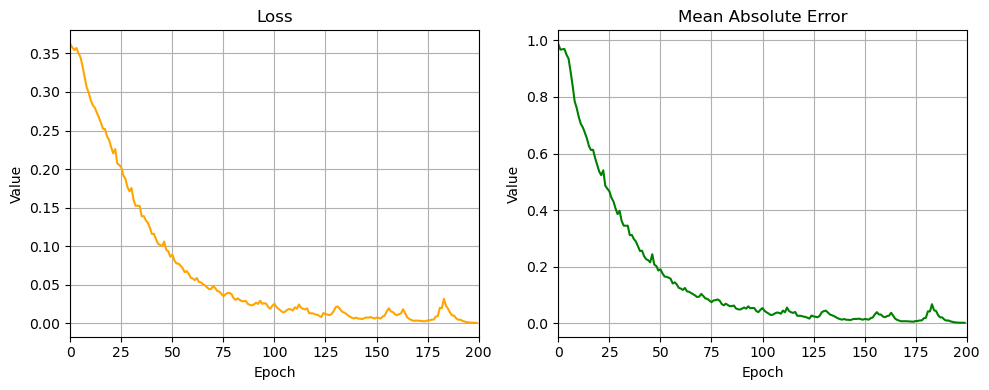

In [39]:
# Create a 1x2 grid for subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))  

# Plot AutoCorrelation Function
axes[0].plot(history.history["loss"], color='orange')
axes[0].set_title("Loss", fontsize=12)
axes[0].set_ylabel("Value")
axes[0].set_xlabel("Epoch")
axes[0].set_xlim(0,200)
axes[0].grid(True)

# Plot Partial Autocorrelation Function
axes[1].plot(history.history["mse"], color='green')
axes[1].set_title("Mean Absolute Error", fontsize=12)
axes[1].set_ylabel("Value")
axes[1].set_xlabel("Epoch")
axes[1].set_xlim(0,200)
axes[1].grid(True)

plt.tight_layout()
plt.show();

In [40]:
def model_forecast(model, series, window_size, batch_size):

    dataset = tf.data.Dataset.from_tensor_slices(series)                 # Generate a TF Dataset from the series values
    dataset = dataset.window(window_size, shift=1, drop_remainder=True)  # Window the data but only take those with the specified size
    dataset = dataset.flat_map(lambda w: w.batch(window_size))           # Flatten the windows by putting its elements in a single batch
    dataset = dataset.batch(batch_size).prefetch(1)                      # Create batches of windows    
    forecast = model.predict(dataset, verbose=0)                         # Get predictions on the entire dataset
    
    return forecast


# Forecast only on features, exclude the target
forecast_series = series[split_time - window_size:-1, :-1]               # shape will be (n, 6)

# Use helper function to generate predictions
forecast = model_forecast(model, forecast_series, window_size, batch_size)

# Drop single dimensional axis
results = forecast.squeeze()

# Get only the pollution column from the scaler's transformation
pollution_index = df.columns.get_loc('pollution')

# Inverse transform predictions 
pollution_mean = scaler.mean_[-1]       # Last column is pollution
pollution_std  = scaler.scale_[-1]

results_unscaled = results * pollution_std + pollution_mean

In [41]:
forecast[:10]  # First 10 values

array([[-1.2677156 ],
       [-1.2157212 ],
       [-1.0356584 ],
       [-0.5319218 ],
       [-0.2706075 ],
       [-0.61439174],
       [ 0.11009742],
       [ 1.1232102 ],
       [ 1.0173311 ],
       [ 1.1384331 ]], dtype=float32)

In [42]:
results_unscaled

array([-3.99600220e+00,  2.37731934e-02,  1.39447861e+01,  5.28896217e+01,
        7.30923309e+01,  4.65137138e+01,  1.02525360e+02,  1.80851059e+02,
        1.72665344e+02,  1.82027969e+02,  1.79366211e+02,  1.20544937e+02,
        2.13627548e+01,  5.75711975e+01,  1.05652115e+02,  4.33394775e+01,
        5.18639221e+01,  5.82559967e+01,  1.07771378e+02,  2.54636337e+02,
        1.35280701e+02,  6.30558205e+01,  2.53348633e+02,  1.79936646e+02,
        5.70693245e+01,  4.34874039e+01,  4.25167542e+01,  4.85880814e+01,
        1.21246124e+02,  1.04355423e+02,  1.60684448e+02,  2.53070282e+02,
        5.68083687e+01,  6.75774384e+01,  6.52544708e+01,  1.47630051e+02,
        6.19982796e+01,  4.16420555e+01,  8.00068893e+01,  7.36020813e+01,
        1.68762314e+02,  2.08077576e+02,  7.18191528e+01,  9.96745987e+01,
        9.33209229e+01,  5.15934143e+01,  1.63965179e+02,  2.99682999e+01,
        3.50555038e+01,  2.38685455e+01,  4.12481194e+01,  1.26737320e+02,
        4.80974655e+01,  

In [43]:
x_train

array([[-7.29434171e-01, -1.52244999e+00,  8.24228441e-01, ...,
         1.20084954e+00, -1.96270217e-01,  6.71886254e-01],
       [-8.44197079e-01, -1.81826960e+00,  6.29819973e-01, ...,
         2.58533111e+01, -1.96270217e-01, -1.96349830e-01],
       [-1.60339785e+00, -2.07440609e+00,  1.27509063e+00, ...,
        -9.66484391e-02, -1.96270217e-01, -8.10744079e-01],
       ...,
       [ 8.56648069e-01,  4.79743694e-01, -3.19960867e-02, ...,
        -9.66484391e-02, -1.96270217e-01, -3.49948392e-01],
       [ 4.82932958e-01,  4.61705913e-01,  2.49275739e-01, ...,
        -9.66484391e-02, -1.96270217e-01, -5.12708974e-01],
       [ 3.27092427e-02, -6.12790366e-05,  9.52455302e-01, ...,
        -9.66484391e-02, -1.96270217e-01, -8.78111870e-01]])

In [44]:
test.tail()

,pollution,dew,temp,press,wnd_spd,snow,rain
date,,,,,,,
2014-12-27,238.666667,-9.666667,-1.791667,1027.833333,9.278333,0.0,0.0
2014-12-28,197.375000,-10.791667,1.583333,1019.958333,10.948750,0.0,0.0
2014-12-29,159.000000,-12.333333,0.750000,1013.750000,8.000000,0.0,0.0
2014-12-30,46.083333,-13.916667,1.875000,1019.125000,9.778333,0.0,0.0
2014-12-31,10.041667,-21.791667,-1.916667,1032.125000,167.458333,0.0,0.0


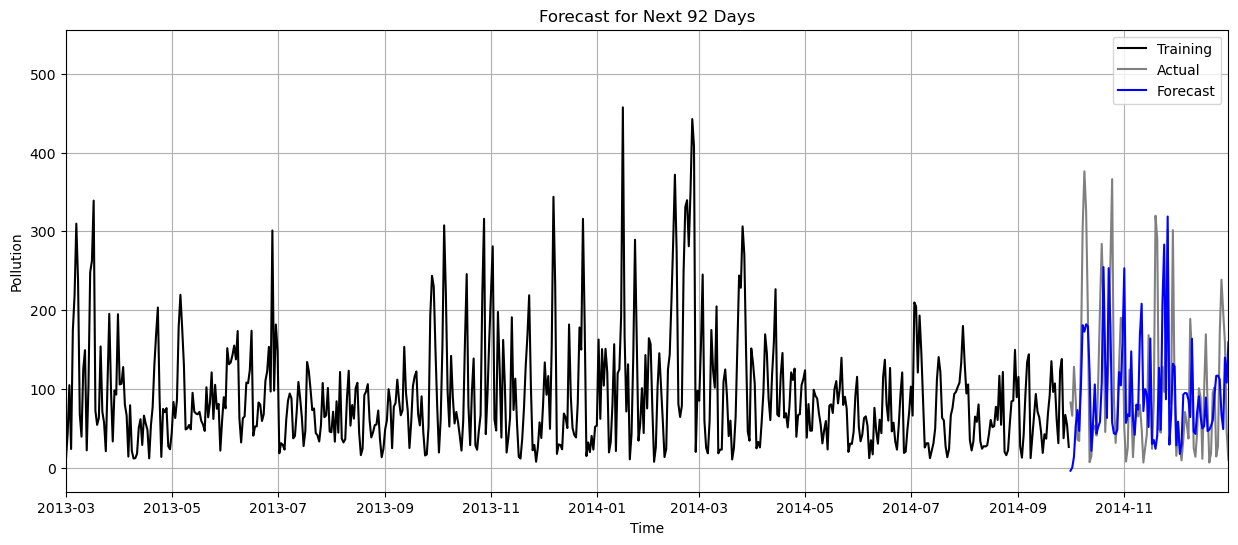

In [45]:
# Plot actual vs. forecast
plt.figure(figsize=(15, 6))
plt.plot(train.index, train['pollution'], label="Training", color='black')    # Train values
plt.plot(test.index, test['pollution'], label="Actual", color='gray')       # Validation values
plt.plot(test.index, results_unscaled, label="Forecast", color='blue')     # Forecast values
plt.title("Forecast for Next 92 Days")
plt.xlim(pd.to_datetime('2013-03-01'), pd.to_datetime('2014-12-31'))
plt.xlabel("Time")
plt.ylabel("Pollution")
plt.legend()
plt.grid(True)
plt.show();

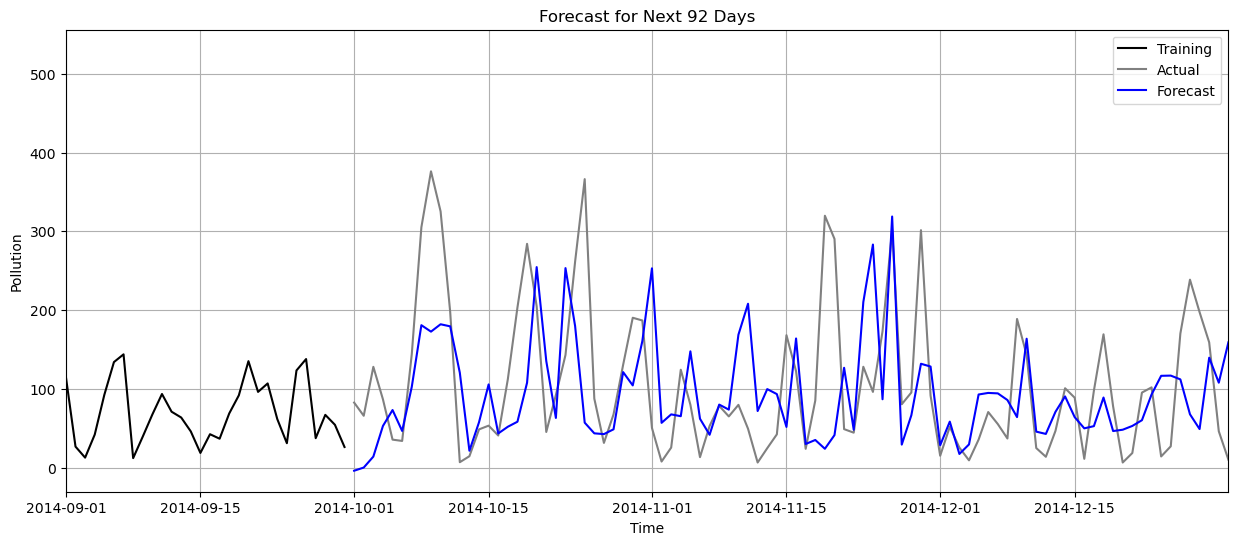

In [46]:
# Plot actual vs. forecast
plt.figure(figsize=(15, 6))
plt.plot(train.index, train['pollution'], label="Training", color='black')    # Train values
plt.plot(test.index, test['pollution'], label="Actual", color='gray')       # Validation values
plt.plot(test.index, results_unscaled, label="Forecast", color='blue')     # Forecast values
plt.title("Forecast for Next 92 Days")
plt.xlim(pd.to_datetime('2014-09-01'), pd.to_datetime('2014-12-31'))
plt.xlabel("Time")
plt.ylabel("Pollution")
plt.legend()
plt.grid(True)
plt.show();

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error


# Metrics
mae_s = mean_absolute_error(test['pollution'], results_unscaled)
rmse_s = np.sqrt(mean_squared_error(test['pollution'], results_unscaled))
mape_s = mean_absolute_percentage_error(test['pollution'], results_unscaled) * 100

# Combine into dictionaries
metrics_S = {
    'MAE': mae_s,
    'RMSE': rmse_s,
    'MAPE': mape_s,
}

# Create DataFrame for Error Analysis
comparison_df = pd.DataFrame([metrics_S]).round(2) 
comparison_df

,MAE,RMSE,MAPE
0,68.83,94.15,145.85


End.